### The following Script Contains:
#### 1. Importing Libraries and Data
#### 2. Model Architechture and Setup
#### 3. Model Compilation and Training
#### 4. Performance Evaluation
#### 5. Prediction Examples

### 1. Import Libraries and Data

In [5]:
# Import Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import os
import operator
import matplotlib.pyplot as plt
import tensorflow as tf
from keras import Input
from keras.models import Sequential
from keras.models import Model
from keras.layers import Conv1D, Conv2D, Dense, BatchNormalization, Flatten, MaxPooling2D, Activation, Dropout
from keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix, accuracy_score, ConfusionMatrixDisplay

In [9]:
# Create path
path = r'/Users/asadagha/Documents/CF Data Analytics/Machine Learning/Achievement 2/Data Sets/Multi-class Weather Dataset'
folders = os.listdir(path)
print(folders)

['Cloudy', 'Rain', '.DS_Store', 'Shine', 'Sunrise']


### 2. Model Architecture and Setup

In [13]:
# Load in the pictures and rescale them to 250x250pixels

datagenerator = ImageDataGenerator(rescale=1/255, validation_split=0.2)
train_generator = datagenerator.flow_from_directory(
    path,
    target_size=(250 , 250),
    batch_size=32,
    subset='training',
)

test_generator = datagenerator.flow_from_directory(
    path,
    target_size=(250 , 250),
    batch_size=32,
    subset='validation',
)

Found 901 images belonging to 4 classes.
Found 224 images belonging to 4 classes.


In [15]:
# This is a CNN to categorize the weather images

inputs = Input(shape=(250, 250, 3))

x = Conv2D(32, (5,5), activation = 'relu')(inputs)
x = MaxPooling2D(3,3)(x)
x = Conv2D(64, (5,5) , activation = 'relu')(x)
x = MaxPooling2D((3,3))(x)
x = Conv2D(128 , (5,5) , activation = 'relu')(x)
x = MaxPooling2D(3,3)(x)
x = Flatten()(x)
x = Dropout(0.5, seed = 5)(x)
x = Dense(128 , activation = 'relu')(x)

outputs = Dense(4, activation = 'softmax')(x)

model:Model = Model(inputs=inputs, outputs=outputs)

### 3. Model Compilation and Training

In [18]:
# Compile and run the model

model.compile(optimizer="Adam", loss="mean_squared_error", metrics=["accuracy"])
model.fit(
    train_generator, 
    epochs = 15, 
    steps_per_epoch = train_generator.n // train_generator.batch_size,
    validation_data = test_generator,
    validation_steps = test_generator.n // test_generator.batch_size,
)

Epoch 1/15


/opt/anaconda3/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


28/28 ━━━━━━━━━━━━━━━━━━━━ 11s 380ms/step - accuracy: 0.3992 - loss: 0.1614 - val_accuracy: 0.5446 - val_loss: 0.1520
Epoch 2/15
 1/28 ━━━━━━━━━━━━━━━━━━━━ 9s 337ms/step - accuracy: 0.6875 - loss: 0.1232

/opt/anaconda3/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:107: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.6875 - loss: 0.1232 - val_accuracy: 0.5312 - val_loss: 0.1588
Epoch 3/15
28/28 ━━━━━━━━━━━━━━━━━━━━ 11s 387ms/step - accuracy: 0.7055 - loss: 0.0955 - val_accuracy: 0.8080 - val_loss: 0.0923
Epoch 4/15
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.8125 - loss: 0.0904 - val_accuracy: 0.7946 - val_loss: 0.0921
Epoch 5/15
28/28 ━━━━━━━━━━━━━━━━━━━━ 11s 378ms/step - accuracy: 0.7765 - loss: 0.0846 - val_accuracy: 0.7455 - val_loss: 0.1094
Epoch 6/15
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.7188 - loss: 0.0913 - val_accuracy: 0.7723 - val_loss: 0.0961
Epoch 7/15
28/28 ━━━━━━━━━━━━━━━━━━━━ 11s 383ms/step - accuracy: 0.8301 - loss: 0.0640 - val_accuracy: 0.7857 - val_loss: 0.0849
Epoch 8/15
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.9062 - loss: 0.0531 - val_accuracy: 0.7545 - val_loss: 0.0931
Epoch 9/15
28/28 ━━━━━━━━━━━━━━━━━━━━ 11s 390ms/step - accuracy: 0.8126 - loss: 0.0701 - val_accuracy: 0.7812 - val_

In [20]:
results = pd.DataFrame(model.history.history)

### 4. Performance Evaluation

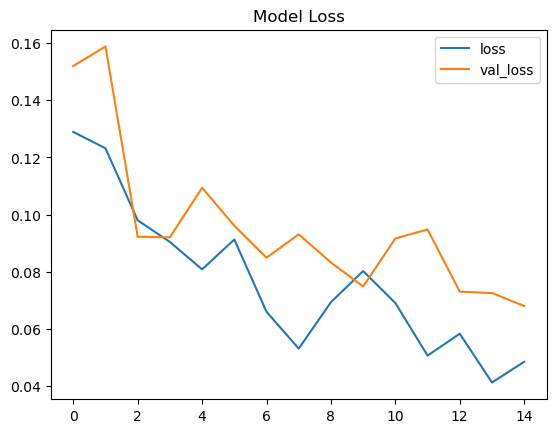

In [23]:
results[['loss','val_loss']].plot(title='Model Loss')
plt.savefig('./loss.png')

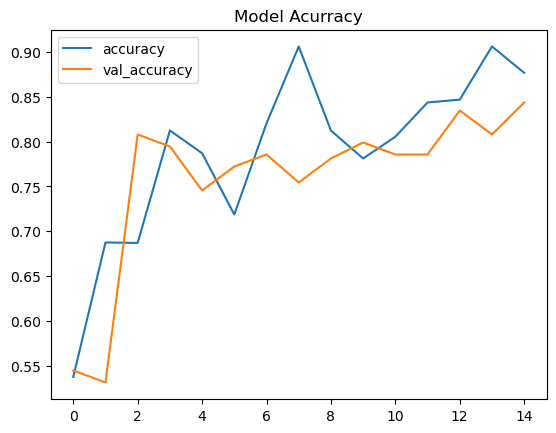

In [25]:
results[['accuracy','val_accuracy']].plot(title='Model Acurracy')
plt.savefig('./accuracy.png')

In [27]:
# Print the accuracy and loss
print("Accuracy: {}, Val_Accuracy: {}".format(results['accuracy'].iloc[-1], results['val_accuracy'].iloc[-1]))
print("Loss: {}, Val_Loss: {}".format(results['loss'].iloc[-1], results['val_loss'].iloc[-1]))

Accuracy: 0.8768699765205383, Val_Accuracy: 0.84375
Loss: 0.04851977899670601, Val_Loss: 0.06805145740509033


21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 85ms/step


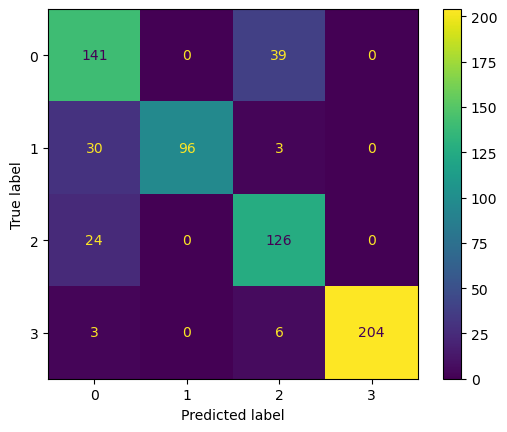

In [29]:
# Collect n batches of images and display the confusion matrix for them.

class_names = ['Cloudy', 'Rain', 'Shine', 'Sunrise']
n = 20 #<--you can change the number of batches selected.

image_batch, classes_batch = next(test_generator)

for batch in range(n):
    temp = next(test_generator)
    image_batch = np.concatenate((image_batch, temp[0]))
    classes_batch = np.concatenate((classes_batch, temp[1]))

classes_batch = classes_batch
y_predict = model.predict(image_batch)

#Confusion matrix for training data
cm = confusion_matrix(y_pred = [np.argmax(x) for x in y_predict], y_true = [np.argmax(x) for x in classes_batch])
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

### 5. Prediction Examples

In [32]:
#This function will display a number of random images as well as the predictions for the type of weather.

def predict_one(model, num_images = None):  
    image_batch, classes_batch = next(test_generator)
    predicted_batch = model.predict(image_batch)
    for k in range(0,image_batch.shape[0] if num_images is None else num_images):
        image = image_batch[k]
        real_class = class_names[np.argmax(classes_batch[k])]
        predicted_class = class_names[np.argmax(predicted_batch[k])]
        value_predicted = predicted_batch[k]
        isTrue = (real_class == predicted_class)
        plt.figure(k)
        plt.title(str("Correct Prediction" if isTrue else "Incorrect Prediction") + ' - class: ' + real_class + ' - ' + 'predicted: ' + predicted_class + str(value_predicted))
        plt.axis('off')
        plt.savefig('./' + real_class + '_' + predicted_class + '_' + str(value_predicted) + '.png')
        plt.imshow(image)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step


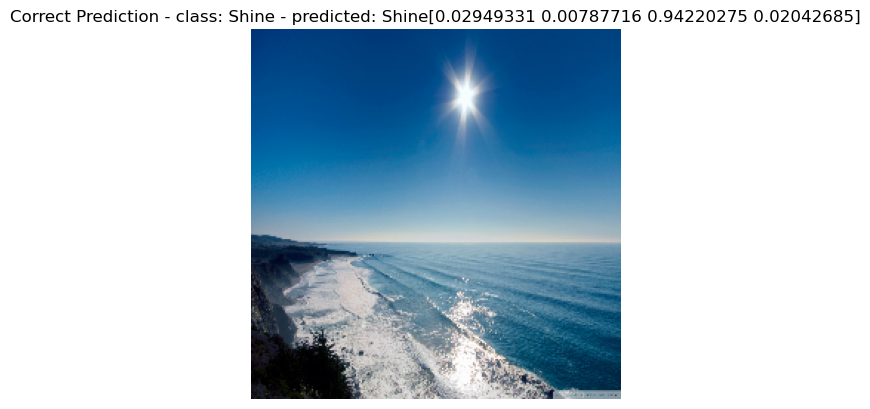

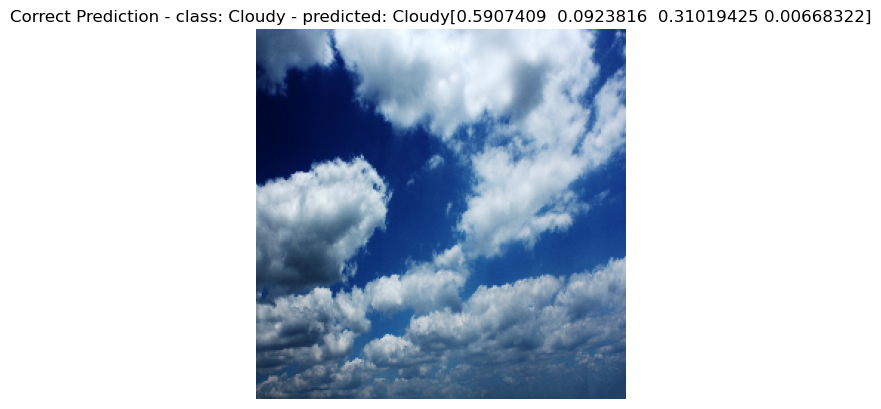

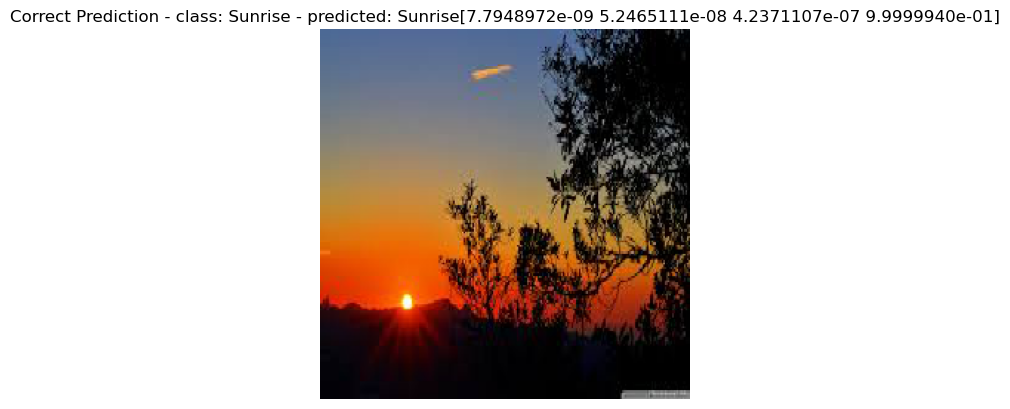

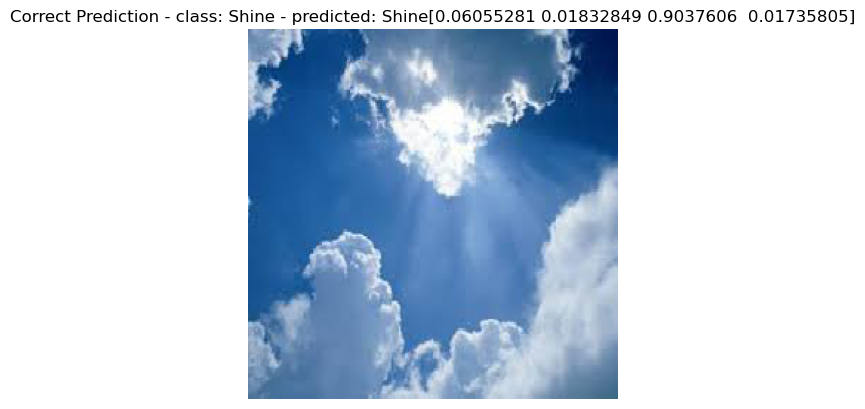

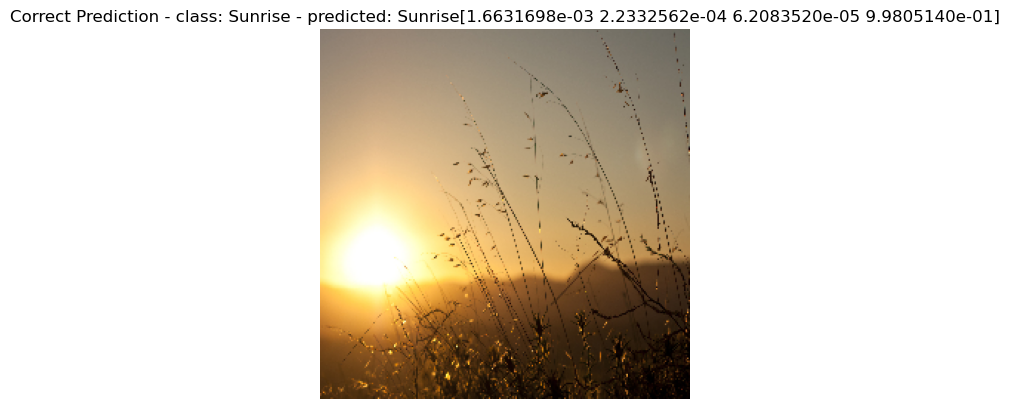

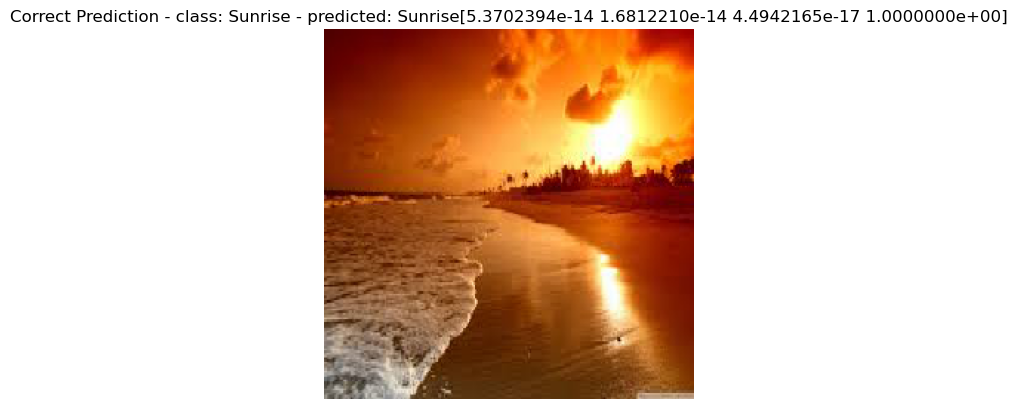

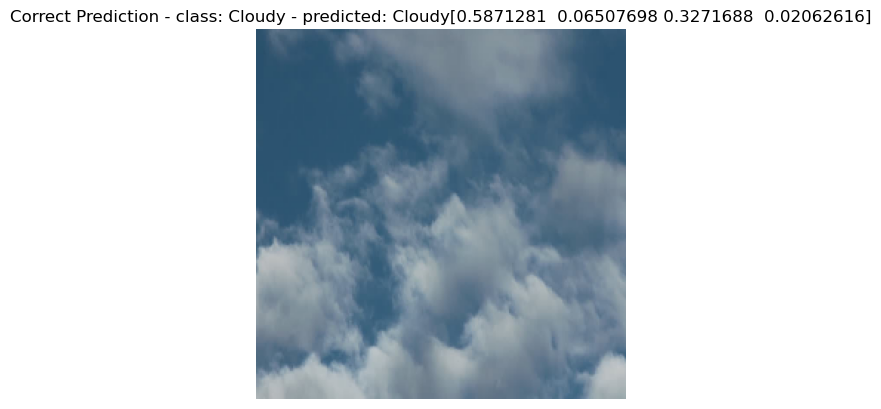

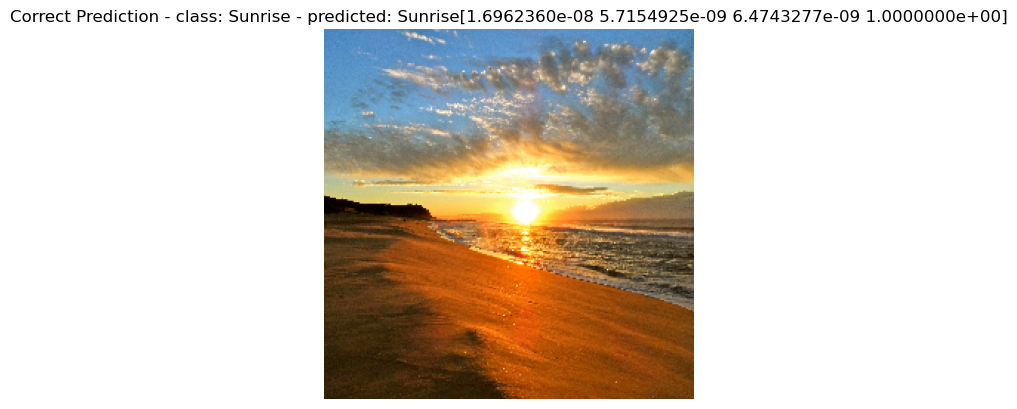

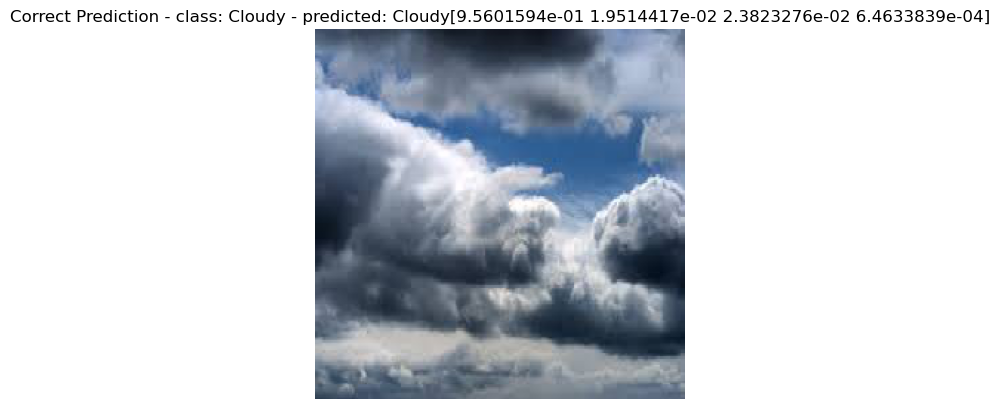

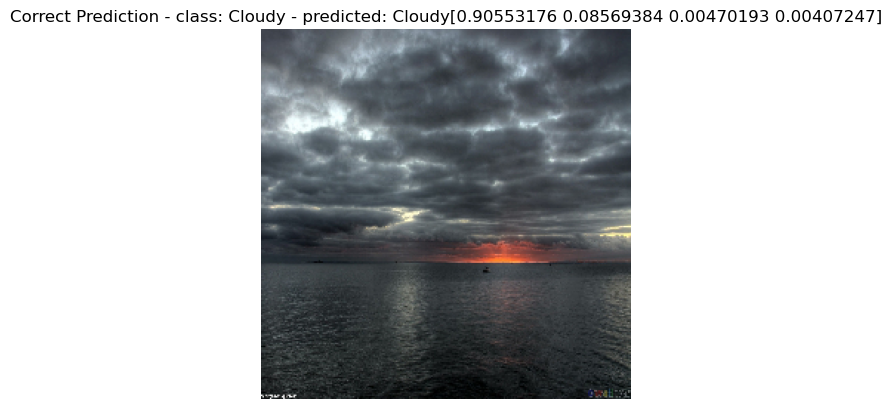

In [34]:
predict_one(model, 10) #<--you can show multiple pictures with this command. Just fill in the number you want to see.